# Configuration set-up and variable settings

In [1]:
import os
import warnings
import ssl

import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
#from classification_models.tfkeras import Classifiers

import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization 
from keras.layers import RandomFlip, RandomRotation, RandomZoom, LeakyReLU, GlobalAveragePooling2D
from keras.optimizers import Adam, SGD
from keras.losses import SparseCategoricalCrossentropy
from keras.regularizers import l2 


In [2]:
tf.get_logger().setLevel('ERROR')

warnings.filterwarnings("ignore")
ssl._create_default_https_context = ssl._create_unverified_context

# Select TensorFlow's backend
os.environ["KERAS_BACKEND"] = "tensorflow"

# Select hardware accelerator (GPU)
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
gpu_devices = tf.config.list_physical_devices("GPU")
if gpu_devices:
    details = tf.config.experimental.get_device_details(gpu_devices[0])
    gpu_name = details.get("device_name", "Name not found")
    print(f"Available GPU: {gpu_name}")
else:
    print("No GPU detected.")

print(f"Keras version: {keras.__version__}")

seed = 42
keras.utils.set_random_seed(seed)
np.random.seed(seed)

Available GPU: NVIDIA GeForce GTX 1660 Ti
Keras version: 3.14.0


Some utility function are defined below:

In [3]:
def plot_history(history):
    plt.figure(figsize=(20, 3))
    for i, metric in enumerate(["accuracy", "loss"]):
        plt.subplot(1, 2, i + 1) 
        plt.plot(history.history[metric])
        plt.plot(history.history["val_" + metric])
        plt.title("Model {}".format(metric))
        plt.xlabel("epochs")
        plt.ylabel(metric)
        plt.legend(["train", "val"])


In [4]:
IMG_SHAPE = (256, 256) 
BATCH_SIZE = 32
EPOCHS = 150
METRICS = ["accuracy"]

PATIENCE_STOP = 10
PATIENCE_PLAT = 5
INIT_LR = 1e-3

# Data import, inspection and pre-processing

### Data Import

In [5]:
dataset_split = ["train[:80%]", "train[80%:]", "test[:60%]", "test[60%:80%]", "test[80%:]"]
(train_split, val_split, extra_train, extra_val, test_data), info = tfds.load(
    "oxford_iiit_pet", 
    split=dataset_split, 
    as_supervised=True, 
    with_info=True
)

train_split = train_split.concatenate(extra_train)
val_split   = val_split.concatenate(extra_val)

### Data Inspection

In [6]:
def get_labels(dataset):
    return np.array([label.numpy() for _, label in dataset])

y_train_labels = get_labels(train_split)
y_val_labels   = get_labels(val_split)
y_test_labels  = get_labels(test_data)

print(f"Train samples: {len(y_train_labels)}")
print(f"Val samples:   {len(y_val_labels)}")
print(f"Test samples:  {len(y_test_labels)}")

_, train_count      = np.unique(y_train_labels, return_counts=True)
_, validation_count = np.unique(y_val_labels,   return_counts=True)
_, test_count       = np.unique(y_test_labels,  return_counts=True)

distribution = pd.DataFrame({
    "Class": info.features["label"].names,
    "Train%":      (train_count / len(y_train_labels)) * 100,
    "Validation%": (validation_count / len(y_val_labels)) * 100,
    "Test%":       (test_count / len(y_test_labels)) * 100,
    "Train":      train_count,
    "Validation": validation_count,
    "Test":       test_count,
})
distribution["Total count"] = distribution["Train"] + distribution["Validation"] + distribution["Test"]
distribution = distribution.round(2)

## Print results
print(f"Perfectly balanced dataset distribution if ~={100/len(distribution):.2f}%:")
distribution

Train samples: 5145
Val samples:   1470
Test samples:  734
Perfectly balanced dataset distribution if ~=2.70%:


,Class,Train%,Validation%,Test%,Train,Validation,Test,Total count
0,Abyssinian,2.59,3.06,2.72,133,45,20,198
1,american_bulldog,2.74,2.65,2.72,141,39,20,200
2,american_pit_bull_terrier,2.82,2.11,3.27,145,31,24,200
3,basset_hound,2.66,2.86,2.86,137,42,21,200
4,beagle,2.60,2.65,3.68,134,39,27,200
5,Bengal,2.76,2.79,2.32,142,41,17,200
6,Birman,2.70,2.79,2.72,139,41,20,200
7,Bombay,2.43,2.59,2.86,125,38,21,184
8,boxer,2.64,2.99,2.59,136,44,19,199
9,British_Shorthair,2.90,2.24,2.45,149,33,18,200


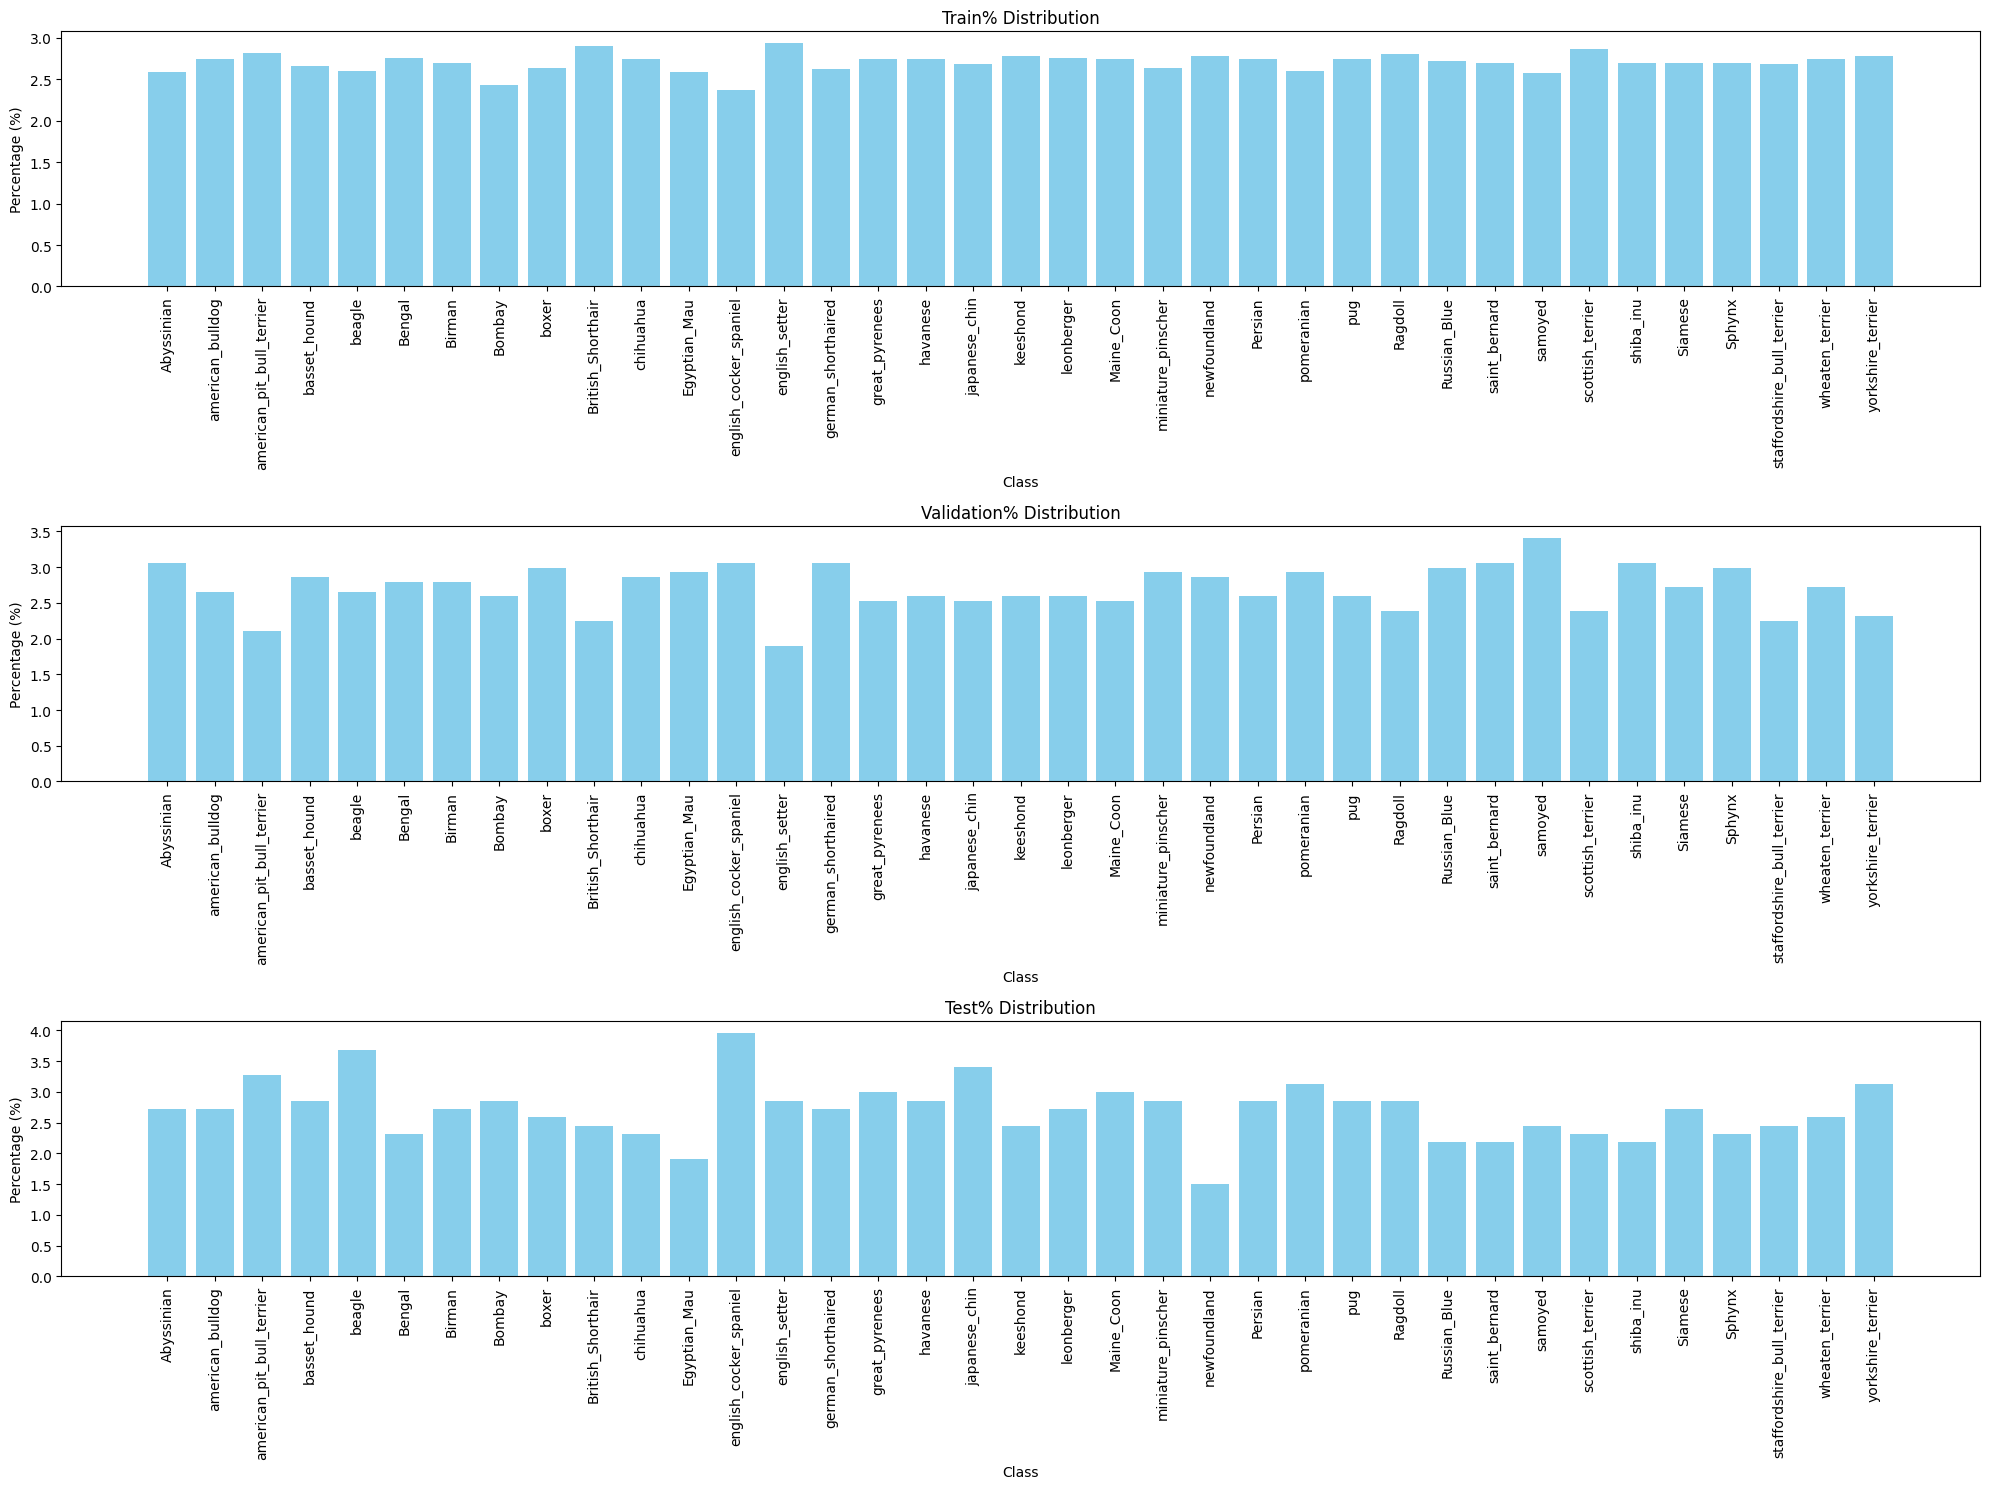

In [7]:
fig, ax = plt.subplots(3, 1, figsize=(20, 15))
ax = ax.flatten()

for idx in range(3):
    ax[idx].bar(distribution["Class"], distribution.iloc[:, idx + 1], color="skyblue")
    ax[idx].set_title(f"{distribution.columns[idx + 1]} Distribution")
    ax[idx].set_xlabel("Class")
    ax[idx].set_ylabel("Percentage (%)")
    ax[idx].set_xticklabels(distribution["Class"], rotation=90)

plt.tight_layout()
plt.show()

In [8]:
labels      = {i: label for i, label in enumerate(info.features["label"].names)}
n_train     = len(y_train_labels)
n_classes   = info.features["label"].num_classes

In [9]:
input_shape = (IMG_SHAPE[0], IMG_SHAPE[1], 3) # 3 channels for RGB
print(f"Input shape: {input_shape}")

Input shape: (256, 256, 3)


### Pre-processing

In [10]:
def dataset_preprocess(img, label):
    img = tf.image.resize_with_pad(img, IMG_SHAPE[0], IMG_SHAPE[1])
    img = tf.cast(img, tf.float32) / 255.0

    return img, label

def train_preprocess(img, label):
    img = tf.image.resize_with_pad(img, IMG_SHAPE[0], IMG_SHAPE[1])
    img = tf.cast(img, tf.float32) / 255.0

    img = tf.image.random_flip_left_right(img)

    ## Color jittering
    img = tf.image.random_brightness(img, 0.2)      # Range of brightness adjustment [-0.2, 0.2]
    img = tf.image.random_contrast(img, 0.8, 1.2)   # Range of contrast adjustment [0.8, 1.2]
    img = tf.image.random_saturation(img, 0.8, 1.2) # Range of saturation adjustment [0.8, 1.2]
    img = tf.image.random_hue(img, 0.05)            # Range of hue adjustment [-0.05, 0.05]
    
    ## Cropping the image: 
    ## 1. resize it to have a "bigger" image of resize_perc
    ## 2. randomly crop. Output image size is the same of the original
    resize_perc = 1.1 
    new_size = [int(IMG_SHAPE[0] * resize_perc), int(IMG_SHAPE[1] * resize_perc)]
    resized_img = tf.image.resize(img, new_size)
    img = tf.image.random_crop(resized_img, size=[IMG_SHAPE[0], IMG_SHAPE[1], 3])
    
    ## to avoid pixel value overflow after color jittering and cropping (i.e. range [0, 1])
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

In [11]:
## Shuffle all the training set (n_train) and apply data augmentation only to the training set
## use the tf.data.AUTOTUNE to optimize the data loading and preprocessing pipeline by parallelizing the operations
train_ds = train_split.shuffle(n_train).map(train_preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(2)

## Apply the same preprocessing to the validation and test sets, but without data augmentation and shuffling
val_ds   = val_split.map(dataset_preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(2)
test_ds  = test_data.map(dataset_preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(2)


In [12]:
input_shape = (IMG_SHAPE[0], IMG_SHAPE[1], 3) # 3 channels for RGB
print(f"Input shape: {input_shape}")

Input shape: (256, 256, 3)


# 01.03 Model implementation 

In [13]:
k_size = (3, 3)
model = Sequential([
    
    # Input layer
    Input(shape = input_shape),

    # BLOCK 1
    Conv2D(filters = 32, kernel_size = k_size, activation = "relu", padding = "same"),
    Conv2D(filters = 32, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # BLOCK 2
    Conv2D(filters = 64, kernel_size = k_size, activation = "relu", padding = "same"),
    Conv2D(filters = 64, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # BLOCK 3
    Conv2D(filters = 128, kernel_size = k_size, activation = "relu", padding = "same"),
    Conv2D(filters = 128, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # BLOCK 4
    Conv2D(filters = 256, kernel_size = k_size, activation = "relu", padding = "same"),
    Conv2D(filters = 256, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Classifier
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dense(units = n_classes, activation = "softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250,501 (4.77 MB)

 Trainable params: 1,249,029 (4.76 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [14]:
opt         = Adam(learning_rate = INIT_LR)
loss_fcn    = SparseCategoricalCrossentropy()
model.compile(loss=loss_fcn, optimizer=opt, metrics=METRICS)

callbacks = [
    ## Restore the best weights of the model based on the validation loss, with a patience of EPOCHS epochs
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE_STOP, restore_best_weights=True, verbose=1),
]

history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, callbacks=callbacks);  

Epoch 1/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.0433 - loss: 3.7503 - val_accuracy: 0.0238 - val_loss: 5.4630
Epoch 2/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 230ms/step - accuracy: 0.0647 - loss: 3.5296 - val_accuracy: 0.0306 - val_loss: 5.0994
Epoch 3/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 231ms/step - accuracy: 0.0896 - loss: 3.4275 - val_accuracy: 0.0469 - val_loss: 3.9400
Epoch 4/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 230ms/step - accuracy: 0.1182 - loss: 3.2683 - val_accuracy: 0.0490 - val_loss: 3.9756
Epoch 5/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 231ms/step - accuracy: 0.1473 - loss: 3.1095 - val_accuracy: 0.0864 - val_loss: 4.2712
Epoch 6/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 231ms/step - accuracy: 0.1825 - loss: 2.9369 - val_accuracy: 0.1381 - val_loss: 3.3423
Epoch 7/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 231ms/step - accuracy: 0.2313 - loss: 2.6926 - val_accuracy: 0.0673 - val_loss: 4.3014
Epoch 8/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 231ms/step - accuracy: 0.2760 - l

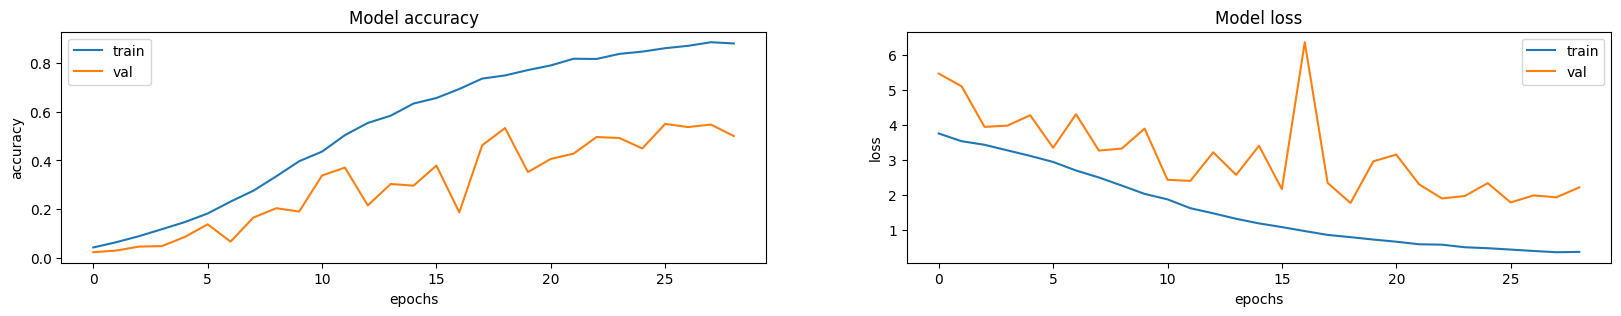

In [15]:
plot_history(history)

In [16]:
test_loss, test_metric = model.evaluate(test_ds, verbose=0)
pred = model.predict(test_ds, verbose=0)

print(f"The test loss is {test_loss:.4f}, the test accuracy is {test_metric:.4f}.")
print("Test output shape: {}".format(pred.shape))

The test loss is 1.8645, the test accuracy is 0.4973.
Test output shape: (734, 37)
